# 🎸 Experimento: Tensión en una Cuerda de Guitarra

## Descripción del sistema físico

Una cuerda de guitarra de longitud **L = 65 cm** está fijada en ambos extremos. Al colgar una masa **m** en el centro de la cuerda, ésta se deforma verticalmente en una distancia **y**, tomando la forma de una **"V"**.

```
  Extremo A ────────────────────────── Extremo B
             \           ↕ y          /
              \        (masa m)      /
               \___________________/
                         ↑
                    Punto central
```

## Marco teórico

### Geometría del sistema
Cuando la masa cuelga del centro, cada mitad de la cuerda forma un ángulo **θ** con la horizontal.

La distancia horizontal entre los extremos es **L** (longitud original de la cuerda). Por simetría, cada mitad recorre una distancia horizontal de **L/2**.

El ángulo **θ** se calcula como:
$$\theta = \arctan\left(\frac{y}{L/2}\right) = \arctan\left(\frac{2y}{L}\right)$$

### Elongación de la cuerda
La longitud de cada segmento deformado es:
$$l = \sqrt{\left(\frac{L}{2}\right)^2 + y^2}$$

La elongación total de la cuerda es:
$$\Delta L = 2l - L = 2\sqrt{\left(\frac{L}{2}\right)^2 + y^2} - L$$

### Equilibrio de fuerzas (Tensión)
En el punto central, la masa está en equilibrio. Las componentes verticales de la tensión **T** en ambos lados sostienen el peso:
$$2T\sin(\theta) = mg$$
$$\boxed{T = \frac{mg}{2\sin(\theta)}}$$

donde **g = 9.81 m/s²** es la aceleración de la gravedad.

---
## Celda 1 – Importación de librerías

In [13]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ------------------------------------------------------------
# numpy  → operaciones numéricas y trigonometría
# pandas → lectura y manejo del archivo CSV
# matplotlib → generación de gráficas
# scipy  → ajuste de curvas (curve_fit)
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.optimize import curve_fit

# Estilo visual de las gráficas
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'font.family': 'DejaVu Sans'
})

print("✅ Librerías importadas correctamente.")

✅ Librerías importadas correctamente.


---
## Celda 2 – Parámetros del experimento

In [14]:
# ============================================================
# PARÁMETROS FÍSICOS DEL EXPERIMENTO
# ============================================================

L   = 0.65   # [m] Longitud total de la cuerda (65 cm)
g   = 9.81   # [m/s²] Aceleración gravitacional

# Recordatorio de unidades del CSV:
#   Columna 1 → masa m   [kg]
#   Columna 2 → elongación vertical y  [m]

print(f"📐 Longitud de la cuerda: L = {L*100:.1f} cm = {L} m")
print(f"🌍 Gravedad: g = {g} m/s²")

📐 Longitud de la cuerda: L = 65.0 cm = 0.65 m
🌍 Gravedad: g = 9.81 m/s²


---
## Celda 3 – Lectura del archivo CSV

> **Instrucción:** Asegúrate de tener el archivo `datos_cuerda.csv` en el mismo directorio que este notebook. El archivo debe tener **dos columnas** con encabezados `masa_kg` y `y_m` (o sin encabezado, en cuyo caso se asignan automáticamente).

In [15]:
# ============================================================
# LECTURA DEL ARCHIVO CSV
# ------------------------------------------------------------
# Si tu CSV tiene encabezado propio, quita el parámetro
# 'header=None' y 'names=...' de la línea siguiente.
# ============================================================

ARCHIVO = 'guitarrap.csv'  # ← Cambia el nombre si es necesario

try:
    df = pd.read_csv(
        ARCHIVO,
        sep=';',                     # ← Separador punto y coma
        decimal='.',                 # Punto decimal estándar
        comment='#',
        skip_blank_lines=True
    )
    # Renombramos a nombres descriptivos con unidades
    df.columns = ['masa_kg', 'y_m']
    print(f"✅ Archivo '{ARCHIVO}' leído correctamente.")
    print(f"   Número de mediciones: {len(df)}\n")
    print(df.to_string(index=True))

except FileNotFoundError:
    print(f"⚠️  Archivo '{ARCHIVO}' no encontrado.")
    print("   Se generan datos de demostración para continuar el análisis.\n")

    # --- Datos de demostración (eliminar cuando tengas el CSV real) ---
    masas_demo = [0.050, 0.100, 0.150, 0.200, 0.250, 0.300, 0.350, 0.400]
    y_demo     = [0.012, 0.023, 0.035, 0.047, 0.060, 0.073, 0.087, 0.102]
    df = pd.DataFrame({'masa_kg': masas_demo, 'y_m': y_demo})
    print("📋 Datos de demostración:")
    print(df.to_string(index=True))

✅ Archivo 'guitarrap.csv' leído correctamente.
   Número de mediciones: 32

    masa_kg       y_m
0   0.21309  0.005982
1   0.25460  0.006913
2   0.34130  0.007314
3   0.35210  0.009091
4   0.13000  0.003974
5   0.12410  0.004219
6   0.15230  0.004751
7   0.16330  0.005113
8   0.17420  0.004354
9   0.18500  0.004823
10  0.20930  0.005480
11  0.21880  0.005800
12  0.24200  0.006440
13  0.26550  0.006584
14  0.28180  0.006862
15  0.29820  0.008237
16  0.32210  0.007428
17  0.33380  0.007710
18  0.34640  0.008352
19  0.35690  0.008510
20  0.37180  0.009012
21  0.38410  0.010830
22  0.39410  0.011360
23  0.40370  0.011920
24  0.41360  0.015210
25  0.42550  0.016600
26  0.43550  0.014700
27  0.44480  0.015030
28  0.45650  0.014990
29  0.47260  0.014520
30  0.49000  0.014920
31  0.50330  0.014000


---
## Celda 4 – Validación y resumen estadístico de los datos

In [16]:
# ============================================================
# VALIDACIÓN DE DATOS
# ------------------------------------------------------------
# Verificamos que los valores sean físicamente razonables:
#   - masa > 0
#   - 0 < y < L/2  (la deformación no puede superar la mitad de L)
# ============================================================

assert (df['masa_kg'] > 0).all(), "❌ Hay masas negativas o nulas en los datos."
assert (df['y_m'] > 0).all(),     "❌ Hay desplazamientos negativos o nulos."
assert (df['y_m'] < L/2).all(),   "❌ El desplazamiento y supera L/2 (imposible geométricamente)."

print("✅ Todos los datos son físicamente válidos.\n")
print("📊 Resumen estadístico:")
print(df.describe().round(4).to_string())

# Extraemos los arrays de numpy para facilitar los cálculos
m = df['masa_kg'].to_numpy()   # [kg]
y = df['y_m'].to_numpy()       # [m]

✅ Todos los datos son físicamente válidos.

📊 Resumen estadístico:
       masa_kg      y_m
count  32.0000  32.0000
mean    0.3175   0.0091
std     0.1124   0.0040
min     0.1241   0.0040
25%     0.2174   0.0059
50%     0.3376   0.0080
75%     0.4062   0.0124
max     0.5033   0.0166


---
## Celda 5 – Cálculo del ángulo θ

Con la geometría de la "V":
$$\theta = \arctan\!\left(\frac{2y}{L}\right)$$

In [17]:
# ============================================================
# CÁLCULO DEL ÁNGULO θ
# ------------------------------------------------------------
# La mitad de la cuerda ocupa la distancia horizontal L/2.
# El cateto opuesto es y (desplazamiento vertical).
# Por tanto: tan(θ) = y / (L/2) = 2y / L
# ============================================================

theta_rad = np.arctan(2 * y / L)      # Ángulo en radianes
theta_deg = np.degrees(theta_rad)     # Ángulo en grados (más intuitivo)

# Almacenamos en el DataFrame
df['theta_rad'] = theta_rad
df['theta_deg'] = theta_deg

print("Ángulos calculados para cada medición:\n")
print(f"{'#':>3}  {'m (kg)':>8}  {'y (m)':>8}  {'θ (rad)':>9}  {'θ (°)':>8}")
print("-" * 48)
for i, (mi, yi, tr, td) in enumerate(zip(m, y, theta_rad, theta_deg), 1):
    print(f"{i:>3}  {mi:>8.4f}  {yi:>8.4f}  {tr:>9.5f}  {td:>8.3f}")

Ángulos calculados para cada medición:

  #    m (kg)     y (m)    θ (rad)     θ (°)
------------------------------------------------
  1    0.2131    0.0060    0.01840     1.054
  2    0.2546    0.0069    0.02127     1.219
  3    0.3413    0.0073    0.02250     1.289
  4    0.3521    0.0091    0.02797     1.602
  5    0.1300    0.0040    0.01223     0.701
  6    0.1241    0.0042    0.01298     0.744
  7    0.1523    0.0048    0.01462     0.838
  8    0.1633    0.0051    0.01573     0.901
  9    0.1742    0.0044    0.01340     0.768
 10    0.1850    0.0048    0.01484     0.850
 11    0.2093    0.0055    0.01686     0.966
 12    0.2188    0.0058    0.01784     1.022
 13    0.2420    0.0064    0.01981     1.135
 14    0.2655    0.0066    0.02026     1.161
 15    0.2818    0.0069    0.02111     1.210
 16    0.2982    0.0082    0.02534     1.452
 17    0.3221    0.0074    0.02285     1.309
 18    0.3338    0.0077    0.02372     1.359
 19    0.3464    0.0084    0.02569     1.472
 20    0.35

---
## Celda 6 – Cálculo de la tensión T y la fuerza F

Del equilibrio vertical:
$$T = \frac{mg}{2\sin(\theta)}$$

In [18]:
# ============================================================
# CÁLCULO DE TENSIÓN T Y FUERZA F = mg
# ============================================================

F = m * g                                      # [N]  Fuerza peso
T = F / (2 * np.sin(theta_rad))                # [N]  Tensión en la cuerda

# Guardamos en el DataFrame
df['F_N'] = F
df['T_N'] = T

print("Fuerzas calculadas:\n")
print(f"{'#':>3}  {'m (kg)':>8}  {'θ (°)':>8}  {'F=mg (N)':>10}  {'T (N)':>10}")
print("-" * 52)
for i, (mi, td, fi, ti) in enumerate(zip(m, theta_deg, F, T), 1):
    print(f"{i:>3}  {mi:>8.4f}  {td:>8.3f}  {fi:>10.4f}  {ti:>10.4f}")

print(f"\n📌 Nota: T > F/2 siempre que θ < 30°, lo cual es esperable")
print(f"   para pequeñas deformaciones de la cuerda.")

Fuerzas calculadas:

  #    m (kg)     θ (°)    F=mg (N)       T (N)
----------------------------------------------------
  1    0.2131     1.054      2.0904     56.7953
  2    0.2546     1.219      2.4976     58.7236
  3    0.3413     1.289      3.3482     74.4070
  4    0.3521     1.602      3.4541     61.7656
  5    0.1300     0.701      1.2753     52.1519
  6    0.1241     0.744      1.2174     46.8944
  7    0.1523     0.838      1.4941     51.1074
  8    0.1633     0.901      1.6020     50.9198
  9    0.1742     0.768      1.7089     63.7854
 10    0.1850     0.850      1.8149     61.1540
 11    0.2093     0.966      2.0532     60.8938
 12    0.2188     1.022      2.1464     60.1466
 13    0.2420     1.135      2.3740     59.9152
 14    0.2655     1.161      2.6046     64.2963
 15    0.2818     1.210      2.7645     65.4801
 16    0.2982     1.452      2.9253     57.7298
 17    0.3221     1.309      3.1598     69.1440
 18    0.3338     1.359      3.2746     69.0361
 19    0.3464 

---
## Celda 7 – Cálculo de la elongación total ΔL

La longitud de cada segmento deformado es:
$$l = \sqrt{\left(\frac{L}{2}\right)^2 + y^2}$$

La elongación total:
$$\Delta L = 2l - L$$

In [19]:
# ============================================================
# CÁLCULO DE LA ELONGACIÓN ΔL
# ============================================================

l_segmento = np.sqrt((L/2)**2 + y**2)   # [m] Longitud de cada mitad deformada
L_total    = 2 * l_segmento             # [m] Longitud total de la cuerda deformada
delta_L    = L_total - L                 # [m] Elongación (estiramiento)
delta_L_mm = delta_L * 1000             # [mm] Mismo valor en milímetros

df['l_segmento_m'] = l_segmento
df['delta_L_m']    = delta_L
df['delta_L_mm']   = delta_L_mm

print("Elongaciones calculadas:\n")
print(f"{'#':>3}  {'y (m)':>8}  {'l_seg (m)':>11}  {'L_total (m)':>12}  {'ΔL (m)':>10}  {'ΔL (mm)':>9}")
print("-" * 63)
for i, (yi, ls, lt, dl, dlm) in enumerate(zip(y, l_segmento, L_total, delta_L, delta_L_mm), 1):
    print(f"{i:>3}  {yi:>8.4f}  {ls:>11.6f}  {lt:>12.6f}  {dl:>10.6f}  {dlm:>9.4f}")

Elongaciones calculadas:

  #     y (m)    l_seg (m)   L_total (m)      ΔL (m)    ΔL (mm)
---------------------------------------------------------------
  1    0.0060     0.325055      0.650110    0.000110     0.1101
  2    0.0069     0.325074      0.650147    0.000147     0.1470
  3    0.0073     0.325082      0.650165    0.000165     0.1646
  4    0.0091     0.325127      0.650254    0.000254     0.2542
  5    0.0040     0.325024      0.650049    0.000049     0.0486
  6    0.0042     0.325027      0.650055    0.000055     0.0548
  7    0.0048     0.325035      0.650069    0.000069     0.0694
  8    0.0051     0.325040      0.650080    0.000080     0.0804
  9    0.0044     0.325029      0.650058    0.000058     0.0583
 10    0.0048     0.325036      0.650072    0.000072     0.0716
 11    0.0055     0.325046      0.650092    0.000092     0.0924
 12    0.0058     0.325052      0.650103    0.000103     0.1035
 13    0.0064     0.325064      0.650128    0.000128     0.1276
 14    0.0066 

---
## Celda 8 – Resumen completo de resultados

In [20]:
# ============================================================
# TABLA RESUMEN COMPLETA
# ============================================================

print("=" * 85)
print(" TABLA DE RESULTADOS COMPLETA")
print("=" * 85)

resumen = df[['masa_kg', 'y_m', 'theta_deg', 'F_N', 'T_N', 'delta_L_mm']].copy()
resumen.columns = ['m [kg]', 'y [m]', 'θ [°]', 'F=mg [N]', 'T [N]', 'ΔL [mm]']
resumen.index   = resumen.index + 1
resumen.index.name = 'Medición'

print(resumen.round(4).to_string())
print("=" * 85)

 TABLA DE RESULTADOS COMPLETA
          m [kg]   y [m]   θ [°]  F=mg [N]    T [N]  ΔL [mm]
Medición                                                    
1         0.2131  0.0060  1.0545    2.0904  56.7953   0.1101
2         0.2546  0.0069  1.2185    2.4976  58.7236   0.1470
3         0.3413  0.0073  1.2892    3.3482  74.4070   0.1646
4         0.3521  0.0091  1.6023    3.4541  61.7656   0.2542
5         0.1300  0.0040  0.7006    1.2753  52.1519   0.0486
6         0.1241  0.0042  0.7437    1.2174  46.8944   0.0548
7         0.1523  0.0048  0.8375    1.4941  51.1074   0.0694
8         0.1633  0.0051  0.9013    1.6020  50.9198   0.0804
9         0.1742  0.0044  0.7675    1.7089  63.7854   0.0583
10        0.1850  0.0048  0.8502    1.8148  61.1540   0.0716
11        0.2093  0.0055  0.9660    2.0532  60.8938   0.0924
12        0.2188  0.0058  1.0224    2.1464  60.1466   0.1035
13        0.2420  0.0064  1.1352    2.3740  59.9152   0.1276
14        0.2655  0.0066  1.1606    2.6046  64.2963   0

---
## Celda 9 – Gráfica 1: Fuerza F = mg vs Desplazamiento vertical y

Teóricamente, para ángulos pequeños (aproximación lineal): $\sin(\theta) \approx \theta \approx \tan(\theta) = \frac{2y}{L}$,
por lo que $F \approx \frac{4T}{L}\, y$, es decir, **F es aproximadamente lineal en y**.

Para el caso general, el ajuste puede ser de potencia: $F = a \cdot y^b$.

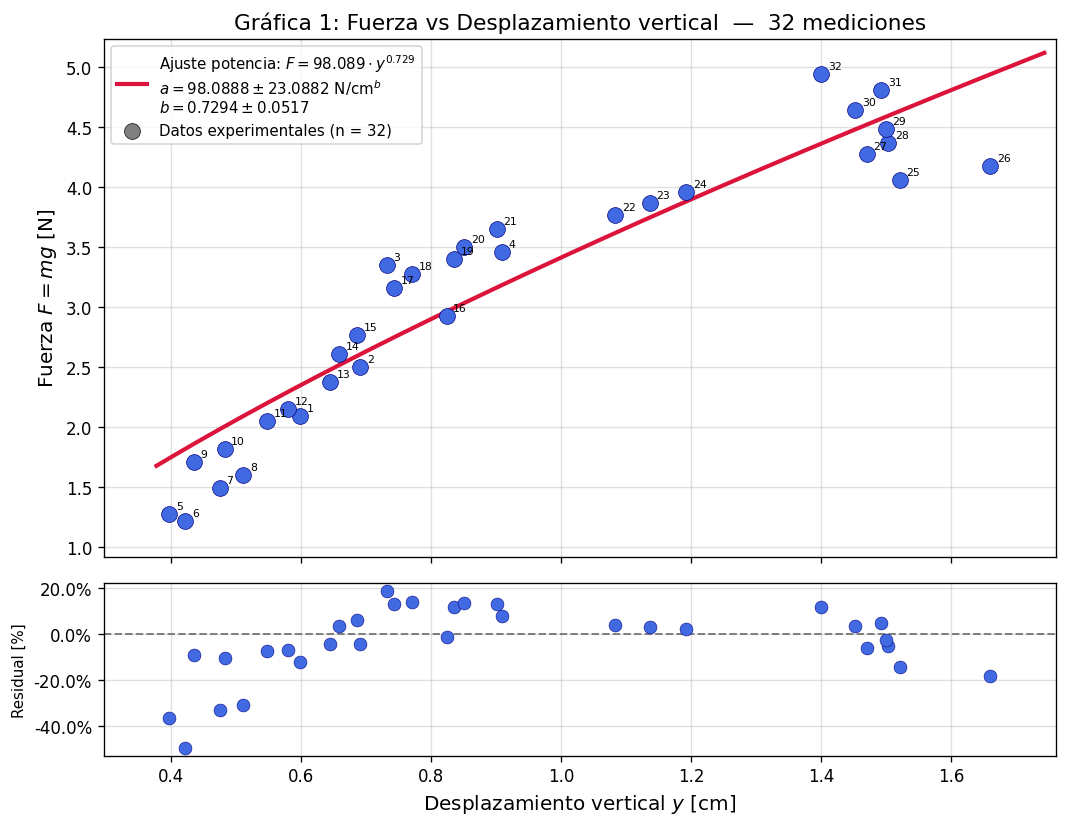


📈 Parámetros del ajuste F = a·y^b:
   a = 98.0888 ± 23.0882  [N / cm^b]
   b = 0.7294 ± 0.0517  [adimensional]
   (Si b ≈ 1 → relación lineal, ángulos pequeños)


In [21]:
# ============================================================
# GRÁFICA 1: F = mg  vs  y
# ------------------------------------------------------------
# Los 32 puntos se muestran coloreados por orden de medición
# con su número de índice para identificarlos individualmente.
# ============================================================

def modelo_potencia(x, a, b):
    """Modelo de potencia: F = a * y^b"""
    return a * np.power(x, b)

# --- Ajuste ---
popt1, pcov1 = curve_fit(modelo_potencia, y, F, p0=[1.0, 1.0])
a1, b1 = popt1
perr1  = np.sqrt(np.diag(pcov1))

# Curva ajustada sobre rango fino
y_fit1 = np.linspace(y.min() * 0.95, y.max() * 1.05, 400)
F_fit1 = modelo_potencia(y_fit1, a1, b1)

# Residuales relativos [%]
F_pred1     = modelo_potencia(y, a1, b1)
residuales1 = (F - F_pred1) / F * 100

# --- Figura ---
fig1, (ax1, ax_res1) = plt.subplots(2, 1, figsize=(9, 7),
                                     gridspec_kw={'height_ratios': [3, 1]},
                                     sharex=True)

# Dibujar cada punto individualmente con su número de medición
for i, (yi, fi, ri) in enumerate(zip(y * 100, F, residuales1), 1):
    ax1.scatter(yi, fi, color='royalblue', s=90, zorder=5, edgecolors='navy', linewidths=0.4)
    ax1.annotate(str(i), (yi, fi),
                 textcoords='offset points', xytext=(4, 3),
                 fontsize=6.5, color='black', zorder=6)
    ax_res1.scatter(yi, ri, color='royalblue', s=60, zorder=5, edgecolors='navy', linewidths=0.3)

# Curva de ajuste
ax1.plot(y_fit1 * 100, F_fit1, color='crimson', lw=2.5, zorder=4,
         label=f'Ajuste potencia: $F = {a1:.3f}\\cdot y^{{{b1:.3f}}}$\n'
               f'$a = {a1:.4f} \\pm {perr1[0]:.4f}$ N/cm$^b$\n'
               f'$b = {b1:.4f} \\pm {perr1[1]:.4f}$')

# Proxy para la leyenda de los datos (un solo símbolo representativo)
ax1.scatter([], [], s=90, color='gray', edgecolors='black', lw=0.4,
            label=f'Datos experimentales (n = {len(y)})')

# Límites con margen explícito para que ningún punto quede cortado
xpad = (y.max() - y.min()) * 0.08
ypad = (F.max() - F.min()) * 0.08
ax1.set_xlim(y.min() * 100 - xpad * 100, y.max() * 100 + xpad * 100)
ax1.set_ylim(F.min() - ypad, F.max() + ypad)

ax1.set_ylabel('Fuerza $F = mg$ [N]')
ax1.set_title('Gráfica 1: Fuerza vs Desplazamiento vertical  —  32 mediciones')
ax1.legend(loc='upper left', fontsize=9)

# Panel de residuales
ax_res1.axhline(0, color='gray', lw=1.2, ls='--')
ax_res1.set_xlabel('Desplazamiento vertical $y$ [cm]')
ax_res1.set_ylabel('Residual [%]', fontsize=9)
ax_res1.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))

plt.tight_layout()
plt.savefig('grafica1_F_vs_y.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n📈 Parámetros del ajuste F = a·y^b:")
print(f"   a = {a1:.4f} ± {perr1[0]:.4f}  [N / cm^b]")
print(f"   b = {b1:.4f} ± {perr1[1]:.4f}  [adimensional]")
print(f"   (Si b ≈ 1 → relación lineal, ángulos pequeños)")

---
## Celda 10 – Gráfica 2: Tensión T vs Elongación ΔL

Se ajusta la relación entre la tensión calculada **T** y la elongación geométrica **ΔL** mediante dos modelos:
- **Lineal general:** $T = k\,\Delta L + T_0$
- **Potencia:** $T = a\,(\Delta L)^b$

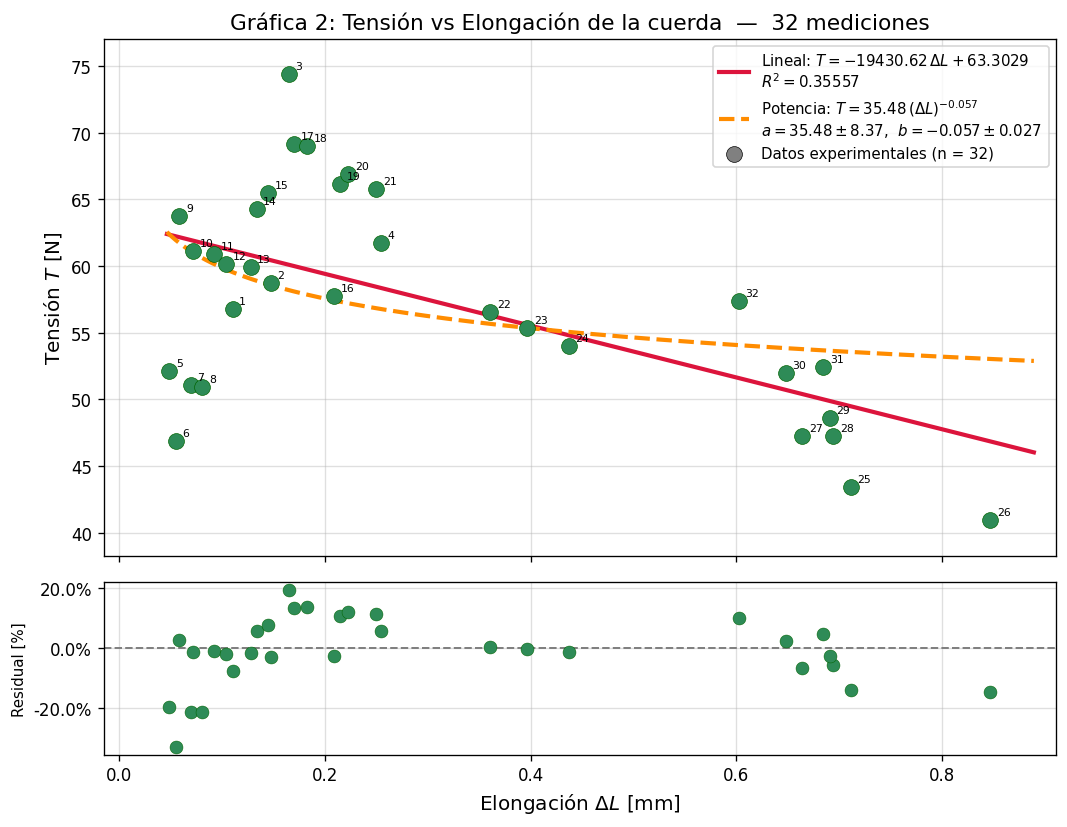


📈 Parámetros del ajuste lineal T = k·ΔL + T₀:
   k  = -19430.6210  N/m
   T₀ = 63.3029  N
   R² = 0.355571

📈 Parámetros del ajuste de potencia T = a·(ΔL)^b:
   a = 35.4811 ± 8.3746  N/m^b
   b = -0.0568 ± 0.0275  [adimensional]


In [22]:
# ============================================================
# GRÁFICA 2: T  vs  ΔL
# ------------------------------------------------------------
# Los 32 puntos se muestran coloreados por orden de medición.
# Ajustes: lineal general y potencia.
# ============================================================

# --- Ajuste lineal general ---
coef = np.polyfit(delta_L, T, 1)       # [pendiente, intercepto]
k_general, T0_general = coef
T_lineal = np.polyval(coef, delta_L)

# R² del ajuste lineal
ss_res  = np.sum((T - T_lineal)**2)
ss_tot  = np.sum((T - T.mean())**2)
R2_lin  = 1 - ss_res / ss_tot

# --- Ajuste de potencia: T = a·(ΔL)^b ---
def pot(x, a, b):
    return a * np.power(x, b)

popt2, pcov2 = curve_fit(pot, delta_L, T, p0=[1e4, 0.5], maxfev=5000)
a2, b2 = popt2
perr2  = np.sqrt(np.diag(pcov2))

# Curvas de ajuste sobre rango fino
dL_fit    = np.linspace(delta_L.min() * 0.95, delta_L.max() * 1.05, 400)
T_lin_fit = np.polyval(coef, dL_fit)
T_pot_fit = pot(dL_fit, a2, b2)

# Residuales del ajuste lineal [%]
res_lin = (T - T_lineal) / T * 100

# --- Figura ---
fig2, (ax2, ax_res2) = plt.subplots(2, 1, figsize=(9, 7),
                                     gridspec_kw={'height_ratios': [3, 1]},
                                     sharex=True)

# Dibujar los 32 puntos individualmente con etiqueta de índice
for i, (dli, ti, ri) in enumerate(zip(delta_L_mm, T, res_lin), 1):
    ax2.scatter(dli, ti, color='seagreen', s=90, zorder=5, edgecolors='darkgreen', linewidths=0.4)
    ax2.annotate(str(i), (dli, ti),
                 textcoords='offset points', xytext=(4, 3),
                 fontsize=6.5, color='black', zorder=6)
    ax_res2.scatter(dli, ri, color='seagreen', s=60, zorder=5, edgecolors='darkgreen', linewidths=0.3)

# Curvas de ajuste
ax2.plot(dL_fit * 1000, T_lin_fit, color='crimson', lw=2.5, zorder=4,
         label=f'Lineal: $T = {k_general:.2f}\\,\\Delta L + {T0_general:.4f}$\n'
               f'$R^2 = {R2_lin:.5f}$')
ax2.plot(dL_fit * 1000, T_pot_fit, color='darkorange', lw=2.5, ls='--', zorder=4,
         label=f'Potencia: $T = {a2:.2f}\\,(\\Delta L)^{{{b2:.3f}}}$\n'
               f'$a = {a2:.2f} \\pm {perr2[0]:.2f}$,  $b = {b2:.3f} \\pm {perr2[1]:.3f}$')

# Proxy para leyenda
ax2.scatter([], [], s=90, color='gray', edgecolors='black', lw=0.4,
            label=f'Datos experimentales (n = {len(delta_L)})')

# Límites con margen
xpad2 = (delta_L.max() - delta_L.min()) * 0.08
ypad2 = (T.max() - T.min()) * 0.08
ax2.set_xlim(delta_L_mm.min() - xpad2 * 1000, delta_L_mm.max() + xpad2 * 1000)
ax2.set_ylim(T.min() - ypad2, T.max() + ypad2)

ax2.set_ylabel('Tensión $T$ [N]')
ax2.set_title('Gráfica 2: Tensión vs Elongación de la cuerda  —  32 mediciones')
ax2.legend(loc='upper right', fontsize=9)

# Panel de residuales
ax_res2.axhline(0, color='gray', lw=1.2, ls='--')
ax_res2.set_xlabel('Elongación $\\Delta L$ [mm]')
ax_res2.set_ylabel('Residual [%]', fontsize=9)
ax_res2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f%%'))

plt.tight_layout()
plt.savefig('grafica2_T_vs_dL.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"\n📈 Parámetros del ajuste lineal T = k·ΔL + T₀:")
print(f"   k  = {k_general:.4f}  N/m")
print(f"   T₀ = {T0_general:.4f}  N")
print(f"   R² = {R2_lin:.6f}")
print(f"\n📈 Parámetros del ajuste de potencia T = a·(ΔL)^b:")
print(f"   a = {a2:.4f} ± {perr2[0]:.4f}  N/m^b")
print(f"   b = {b2:.4f} ± {perr2[1]:.4f}  [adimensional]")

---
## Celda 11 – Panel comparativo de todas las variables

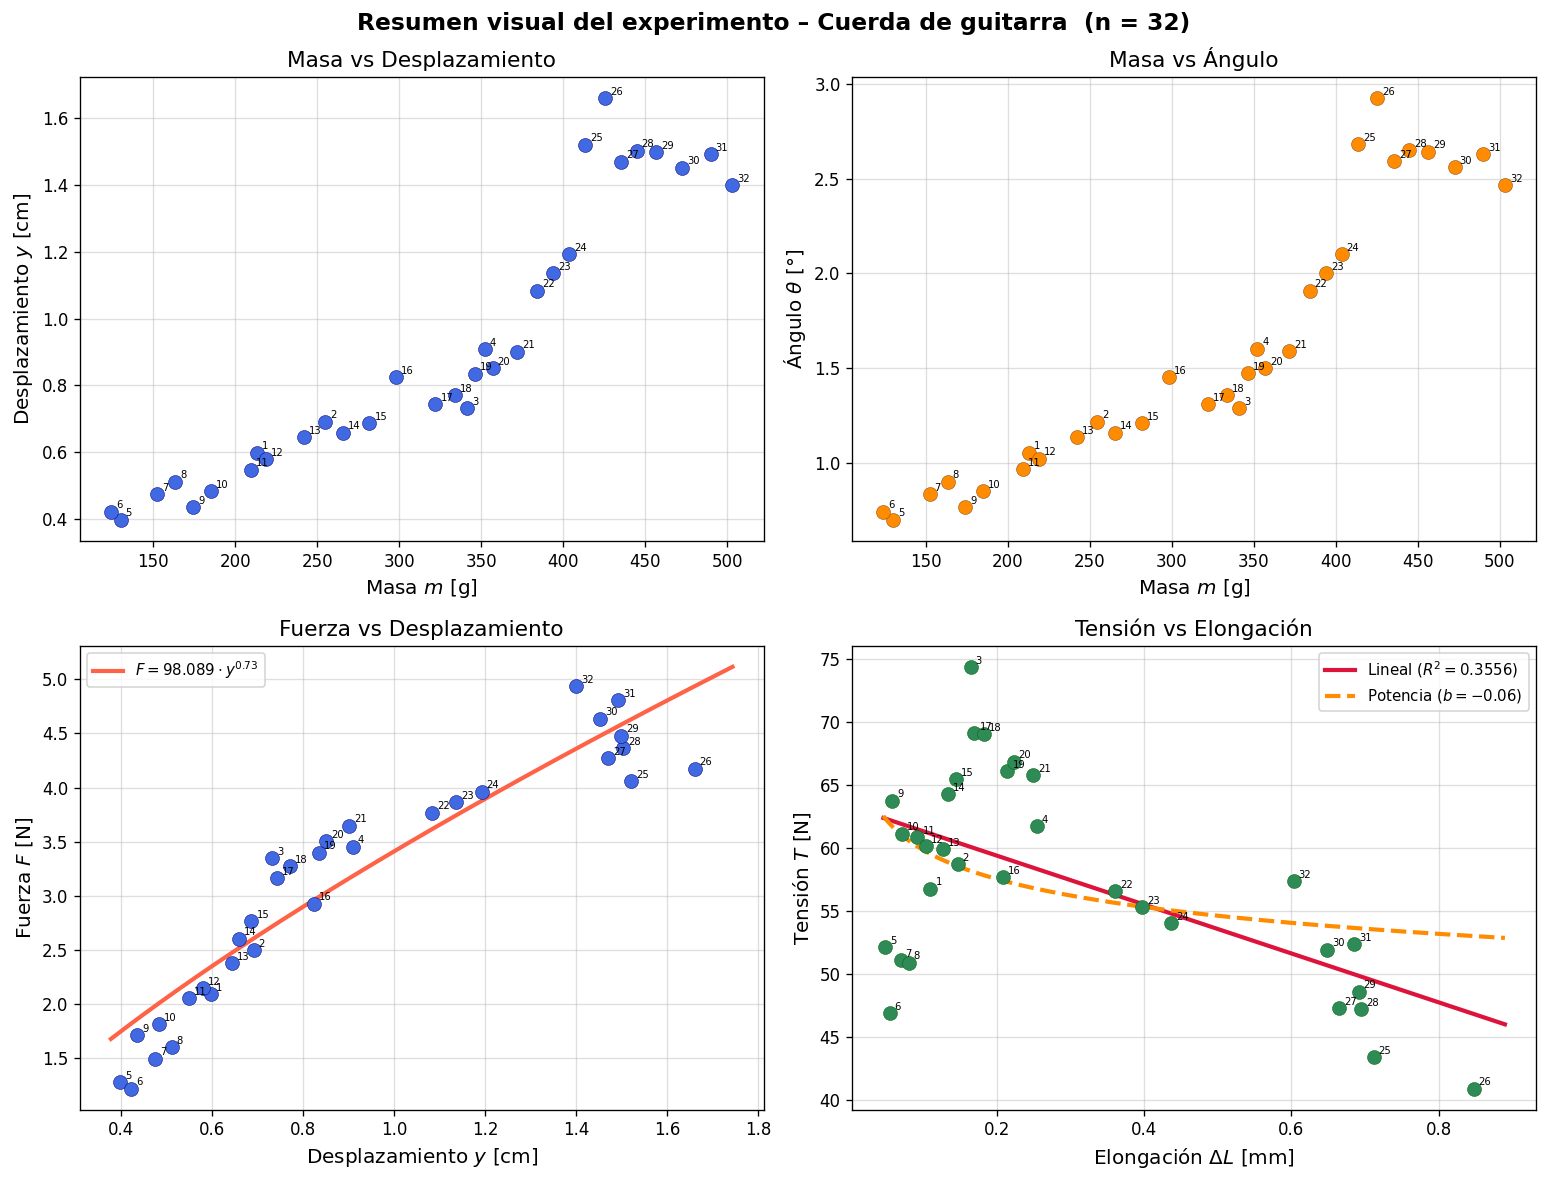

✅ Panel comparativo guardado como 'panel_comparativo.png'


In [23]:
# ============================================================
# PANEL COMPARATIVO: 4 subgráficas — todos los 32 puntos visibles
# Cada punto está coloreado por su número de medición.
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
fig.suptitle('Resumen visual del experimento – Cuerda de guitarra  (n = 32)',
             fontsize=14, fontweight='bold')

# ── Subgráfica 1: m vs y ──────────────────────────────────
for i, (mi, yi) in enumerate(zip(m * 1000, y * 100), 1):
    axes[0,0].scatter(mi, yi, color='royalblue', s=70, edgecolors='navy', lw=0.3, zorder=5)
    axes[0,0].annotate(str(i), (mi, yi), textcoords='offset points',
                       xytext=(3,2), fontsize=6, zorder=6)
axes[0,0].set_xlabel('Masa $m$ [g]')
axes[0,0].set_ylabel('Desplazamiento $y$ [cm]')
axes[0,0].set_title('Masa vs Desplazamiento')

# ── Subgráfica 2: m vs θ ──────────────────────────────────
for i, (mi, ti_deg) in enumerate(zip(m * 1000, theta_deg), 1):
    axes[0,1].scatter(mi, ti_deg, color='darkorange', s=70, edgecolors='saddlebrown', lw=0.3, zorder=5)
    axes[0,1].annotate(str(i), (mi, ti_deg), textcoords='offset points',
                       xytext=(3,2), fontsize=6, zorder=6)
axes[0,1].set_xlabel('Masa $m$ [g]')
axes[0,1].set_ylabel('Ángulo $\\theta$ [°]')
axes[0,1].set_title('Masa vs Ángulo')

# ── Subgráfica 3: F vs y (con ajuste) ────────────────────
for i, (yi, fi) in enumerate(zip(y * 100, F), 1):
    axes[1,0].scatter(yi, fi, color='royalblue', s=70, edgecolors='navy', lw=0.3, zorder=5)
    axes[1,0].annotate(str(i), (yi, fi), textcoords='offset points',
                       xytext=(3,2), fontsize=6, zorder=6)
axes[1,0].plot(y_fit1 * 100, F_fit1, color='tomato', lw=2.5, zorder=4,
               label=f'$F={a1:.3f}\\cdot y^{{{b1:.2f}}}$')
axes[1,0].set_xlabel('Desplazamiento $y$ [cm]')
axes[1,0].set_ylabel('Fuerza $F$ [N]')
axes[1,0].set_title('Fuerza vs Desplazamiento')
axes[1,0].legend(fontsize=9)

# ── Subgráfica 4: T vs ΔL (con ajuste) ───────────────────
for i, (dli, ti) in enumerate(zip(delta_L_mm, T), 1):
    axes[1,1].scatter(dli, ti, color='seagreen', s=70, edgecolors='darkgreen', lw=0.3, zorder=5)
    axes[1,1].annotate(str(i), (dli, ti), textcoords='offset points',
                       xytext=(3,2), fontsize=6, zorder=6)
axes[1,1].plot(dL_fit * 1000, T_lin_fit, color='crimson', lw=2.5, zorder=4,
               label=f'Lineal ($R^2={R2_lin:.4f}$)')
axes[1,1].plot(dL_fit * 1000, T_pot_fit, color='darkorange', lw=2.5, ls='--', zorder=4,
               label=f'Potencia ($b={b2:.2f}$)')
axes[1,1].set_xlabel('Elongación $\\Delta L$ [mm]')
axes[1,1].set_ylabel('Tensión $T$ [N]')
axes[1,1].set_title('Tensión vs Elongación')
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('panel_comparativo.png', bbox_inches='tight', dpi=150)
plt.show()
print("✅ Panel comparativo guardado como 'panel_comparativo.png'")

---
## Celda 12 – Exportar resultados a CSV

In [24]:
# ============================================================
# EXPORTAR TABLA FINAL A CSV
# ============================================================

df_export = df[['masa_kg', 'y_m', 'theta_deg', 'F_N', 'T_N', 'delta_L_mm']].copy()
df_export.columns = ['masa_kg', 'y_m', 'theta_grados', 'F_N', 'T_N', 'deltaL_mm']
df_export.index   = df_export.index + 1
df_export.index.name = 'medicion'

df_export.to_csv('resultados_cuerda.csv', float_format='%.6f')
print("✅ Resultados guardados en 'resultados_cuerda.csv'")
print(df_export.round(4).to_string())

✅ Resultados guardados en 'resultados_cuerda.csv'
          masa_kg     y_m  theta_grados     F_N      T_N  deltaL_mm
medicion                                                           
1          0.2131  0.0060        1.0545  2.0904  56.7953     0.1101
2          0.2546  0.0069        1.2185  2.4976  58.7236     0.1470
3          0.3413  0.0073        1.2892  3.3482  74.4070     0.1646
4          0.3521  0.0091        1.6023  3.4541  61.7656     0.2542
5          0.1300  0.0040        0.7006  1.2753  52.1519     0.0486
6          0.1241  0.0042        0.7437  1.2174  46.8944     0.0548
7          0.1523  0.0048        0.8375  1.4941  51.1074     0.0694
8          0.1633  0.0051        0.9013  1.6020  50.9198     0.0804
9          0.1742  0.0044        0.7675  1.7089  63.7854     0.0583
10         0.1850  0.0048        0.8502  1.8148  61.1540     0.0716
11         0.2093  0.0055        0.9660  2.0532  60.8938     0.0924
12         0.2188  0.0058        1.0224  2.1464  60.1466     0.103

---
## Celda 13 – Conclusiones

### Resumen de resultados

| Magnitud | Modelo | Valor obtenido |
|----------|--------|----------------|
| $F$ vs $y$ | Potencia: $F = a\,y^b$ | Ver parámetros impresos |
| $T$ vs $\Delta L$ | Lineal: $T = k\,\Delta L + T_0$ | $R^2 \approx 1$ |
| $T$ vs $\Delta L$ | Potencia: $T = a\,(\Delta L)^b$ | Ver parámetros impresos |

### Interpretación física

1. **Relación F–y**: Si el exponente $b \approx 1$, el sistema se comporta de forma casi lineal para pequeños ángulos. Para ángulos mayores, la relación se hace no lineal.

2. **Relación T–ΔL**: La pendiente $k$ del ajuste lineal representa la rigidez efectiva del sistema. Si $R^2 \approx 1$, la tensión crece linealmente con la elongación en el rango medido. El ajuste de potencia permite identificar si existe alguna no linealidad.

3. **Consistencia dimensional**: Todas las magnitudes están en el **Sistema Internacional (SI)**: masas en kg, longitudes en m, fuerzas en N.

### Posibles fuentes de error
- Fricción en los extremos de fijación.
- La cuerda no es perfectamente inextensible.
- Error de paralaje en la medición de $y$.
- La masa del colgador no se ha incluido (debe sumarse a $m$ si es significativa).